In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

[Data Source](https://omniweb.gsfc.nasa.gov/ftpbrowser/soho_ephin_flux_hr.html)

In [55]:
proton_flux_df = pd.read_csv('data/enviromental/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+") 

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Lewis\AppData\Local\Temp\ipykernel_5996\2333429118.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  proton_flux_df = pd.read_csv('data/enviromental/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")


# Power Law Spectrum
**[Torres 2025](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024SW003921)**: The 
10 MeV proton intensity is calculated from the differential fluxes in four energy (P4, P8, P25, and P41) channels through an integration over the energy. The P8 proton channel covers an energy range of 7.8–25 MeV, P25 covers 25–40.9 MeV, P41 covers 40.9–53 MeV, while the P4 channel covers 4.3–7.8 MeV. We assume that particles above the P41 channel coverage make little contribution to the integral flux of MeV protons. The integral flux is calculated by summing energy-integrated fluxes in the last three (P8, P25, and P41) channels minus the amount between 7.8 and 10 MeV, which is determined by the integration of a power-law spectrum interpolated using the differential fluxes in the first two channels (P4 and P8) and their mean energies. We use the first two channels to do the interpolation because their fluxes have relatively low error bars due to high count rates in low-energy channels.

Too find channel between 7.8- 10 MeV we fall the Power Law Scale and make use of its invariance:

$\Phi_n = \alpha \nu_n^\beta$ (1)

Using the channels P4 and P8:

$\Phi_4 = \alpha \nu_4^\beta$ (2) 

$\Phi_8 = \alpha \nu_8^\beta$ (3)

Converting frequency to energy: $\nu_n = \frac{\bar{E}_n}{h}$ (4), $h = 4.136 \times 10^{-21} \text{Mev/s}$

Rewriting (2): $\alpha = \frac{\Phi_4}{\nu_4^\beta}$

And then plugging into (3): $\Phi_8 = \Phi_4 \left(\frac{\nu_8}{\nu_4} \right)^\beta$ (5)

Solving for $\beta$: $\beta = \frac{\log [\Phi_8 / \Phi_4]}{\log [\nu_8 / \nu_4]}$

Solving for $\alpha$: $\alpha = \frac{\Phi_4}{\nu_4^\beta}$ With newly discovered $\beta$

Now we can solve the flux over any range we want using our new parameters $\alpha, \beta$: $\Phi_x = \alpha \nu_x^\beta$




In [56]:
def Power_Law_Spectrum_Flux(a_lower_bound_energy, a_upper_bound_energy, a_p4_flux, a_p4_avg_E,  a_p8_flux, a_p8_avg_E):
    h = 4.136e-21 # MeV / s
    a_p4_freq = a_p4_avg_E / h
    a_p8_freq = a_p8_avg_E / h
    new_freq  = (a_lower_bound_energy + a_upper_bound_energy)/(2*h)
    beta_denom = np.log(a_p8_freq / a_p4_freq) 


    if beta_denom != 0 and a_p4_flux != 0:
        beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
    else:
        beta =  np.log(a_p8_flux / 10e-10) / 10e-10
    alpha = a_p4_flux / a_p4_freq**beta
    new_flux = alpha * new_freq ** beta

    return new_flux

In [57]:
new_channel_lower_bound = 7.8
new_channel_upper_bound = 10
p4_avg_energy = (4.3+7.8)/2 # MeV
p8_avg_energy = (25+7.8) / 2 # MeV

proton_flux_df["Px"] = proton_flux_df.apply(
    lambda row: Power_Law_Spectrum_Flux(
        new_channel_lower_bound, 
        new_channel_upper_bound, 
        row["P4"], 
        p4_avg_energy, 
        row["P8"], 
        p8_avg_energy
    ), 
    axis=1
)
proton_flux_df["P_tot"] = proton_flux_df["P4"] + proton_flux_df["P25"] + proton_flux_df["P41"] - proton_flux_df["Px"]
proton_flux_df["Timestamp"] = pd.to_datetime(proton_flux_df["Year"], format="%Y") + pd.to_timedelta(proton_flux_df["DOY"] - 1, unit = "D") + pd.to_timedelta(proton_flux_df["Hour"], unit = "h")
proton_flux_df = proton_flux_df[proton_flux_df["P_tot"] != 1.999980e+06] # Cleaned from error numbers?

print(proton_flux_df)


C:\Users\Lewis\AppData\Local\Temp\ipykernel_5996\2363447353.py:13: RuntimeWarning: overflow encountered in scalar power
  alpha = a_p4_flux / a_p4_freq**beta
C:\Users\Lewis\AppData\Local\Temp\ipykernel_5996\2363447353.py:14: RuntimeWarning: overflow encountered in scalar power
  new_flux = alpha * new_freq ** beta
C:\Users\Lewis\AppData\Local\Temp\ipykernel_5996\2363447353.py:14: RuntimeWarning: invalid value encountered in scalar multiply
  new_flux = alpha * new_freq ** beta
C:\Users\Lewis\AppData\Local\Temp\ipykernel_5996\2363447353.py:12: RuntimeWarning: divide by zero encountered in log
  beta =  np.log(a_p8_flux / 10e-10) / 10e-10
C:\Users\Lewis\AppData\Local\Temp\ipykernel_5996\2363447353.py:13: RuntimeWarning: invalid value encountered in scalar divide
  alpha = a_p4_flux / a_p4_freq**beta
C:\Users\Lewis\AppData\Local\Temp\ipykernel_5996\2363447353.py:10: RuntimeWarning: divide by zero encountered in log
  beta = np.log(a_p8_flux / a_p4_flux) / beta_denom
C:\Users\Lewis\AppData

       Year  DOY  Hour        P4        P8       P25       P41        Px  \
0      1995  342     0  0.000042  0.000020  0.000065  0.000049  0.000032   
1      1995  342     1  0.000028  0.000036  0.000069  0.000061  0.000031   
2      1995  342     2  0.000014  0.000027  0.000068  0.000073  0.000018   
3      1995  342     3  0.000041  0.000034  0.000069  0.000074  0.000038   
4      1995  342     4  0.000028  0.000027  0.000033  0.000062  0.000028   
...     ...  ...   ...       ...       ...       ...       ...       ...   
53899  2002   30    19  0.114190  0.009482  0.000173  0.000050  0.043582   
53900  2002   30    20  0.109340  0.008745  0.000191  0.000054  0.041130   
53901  2002   30    21  0.108360  0.008860  0.000185  0.000046  0.041111   
53902  2002   30    22  0.108220  0.009084  0.000184  0.000053  0.041477   
53903  2002   30    23  0.108360  0.008792  0.000239  0.000109  0.040989   

          P_tot           Timestamp  
0      0.000124 1995-12-08 00:00:00  
1      0.00

# Finding Onset, Peaks, and Ends
No specific technique was explained rather the "program" will sort it. heres my attempt and i will compare with theirs


1 .1235232
2 .6567657
3 .87614567
4 .67986
5 .23548278345
6 .234587589345




In [72]:
def Create_Data(a_indices, a_df):
    proton_fluxes = a_df["P_tot"]
    years         = a_df["Year"]
    DOYs          = a_df["DOY"]
    hours         = a_df["Hour"]

    fluxes = proton_fluxes.loc[a_indices]
    years  = years.loc[a_indices]
    DOY    = DOYs.loc[a_indices]
    hours  = hours.loc[a_indices]
    timestamp = pd.to_datetime(years, format="%Y") + pd.to_timedelta(DOY - 1, unit="D") + pd.to_timedelta(hours, unit="h")

    return fluxes, timestamp

def Find_Peak_Range_Indexes(a_df, a_range):
    proton_fluxes = a_df["P_tot"]
    years         = a_df["Year"]
    DOYs          = a_df["DOY"]
    hours         = a_df["Hour"]


    peak_indices, properties = find_peaks(proton_fluxes.to_list(), height = 10, distance = a_range )
    
    start_onset_indices = peak_indices - np.ones(len(peak_indices)) * a_range
    start_end_indices = peak_indices + np.ones(len(peak_indices)) * a_range

    peak_years = a_df["Year"].iloc[peak_indices]
    peak_DOYs  = a_df["DOY"].iloc[peak_indices]
    peak_hours = a_df["Hour"].iloc[peak_indices]
    peak_dates = pd.to_datetime(peak_years, format="%Y") + pd.to_timedelta(peak_DOYs - 1, unit="D")
    peak_timestamp = peak_dates + pd.to_timedelta(peak_hours, unit="h")
  

    onset_indices = []
    end_indices = []
    threshold_indices = []

    proton_fluxes = proton_fluxes.sort_index()

    for i in range(len(peak_indices)):
        onset_slice = proton_fluxes.iloc[int(start_onset_indices[i]): int(peak_indices[i])]
        onset_min_index = onset_slice.idxmin()
        onset_indices.append(onset_min_index)


        threshold_slice = proton_fluxes.iloc[int(start_onset_indices[i]): int(peak_indices[i])]

        #print(threshold_slice, proton_fluxes.iloc[int(peak_indices[i])], peak_indices[i])

        threshold_geq_10 = threshold_slice[threshold_slice > 10]
        
        if threshold_geq_10.empty:
            threshold_geq_10_index = onset_min_index
        else:

            threshold_geq_10_index = threshold_geq_10.index[0]
       # print(threshold_first_number_greater_than_10)
        threshold_indices.append(threshold_geq_10_index)


        end_slice = proton_fluxes.iloc[int(peak_indices[i]): int(start_end_indices[i])]
        end_min_index = end_slice.idxmin()
        end_indices.append(end_min_index)

    
    onset_fluxes, onset_timestamp = Create_Data(onset_indices, proton_flux_df)
    end_fluxes, end_timestamp     = Create_Data(end_indices, proton_flux_df)
    threshold_fluxes, threshold_timestamp = Create_Data(threshold_indices, proton_flux_df)
    peak_fluxes = pd.Series(properties['peak_heights'])



 ### ADD THRESHOLD ### > 10MeV



    phases_df = pd.DataFrame({'Timestamp Onset': onset_timestamp,
                            'Onset Flux': onset_fluxes,
                            'Threshold Timestamp': threshold_timestamp,
                            'Threshold Flux': threshold_fluxes,
                            'Timestamp Peak': peak_timestamp,
                            'Peak Flux': peak_fluxes,
                            'Timestamp End': end_timestamp,
                            'End_Flux': end_fluxes})
    
    phase_df = phases_df.apply(lambda col : col.dropna().reset_index(drop = True))
    return phase_df
Find_Peak_Range_Indexes(proton_flux_df, 55)
  

,Timestamp Onset,Onset Flux,Threshold Timestamp,Threshold Flux,Timestamp Peak,Peak Flux,Timestamp End,End_Flux
0,1997-11-06 11:00:00,0.806520,1997-11-06 22:00:00,13.861737,1997-11-07 06:00:00,48.236460,1997-11-09 12:00:00,2.031251
1,1998-04-19 23:00:00,0.000400,1998-04-21 00:00:00,11.187188,1998-04-21 10:00:00,31.837132,1998-04-23 11:00:00,3.150870
2,1998-05-06 05:00:00,0.053235,1998-05-06 05:00:00,0.053235,1998-05-06 10:00:00,17.482761,1998-05-08 15:00:00,0.025826
3,1998-11-04 13:00:00,0.000112,1998-11-06 09:00:00,10.984583,1998-11-06 15:00:00,17.353562,1998-11-08 21:00:00,0.289515
4,1998-11-13 07:00:00,0.000530,1998-11-13 07:00:00,0.000530,1998-11-14 13:00:00,13.861132,1998-11-22 06:00:00,0.001218
5,1999-04-22 21:00:00,0.000006,1999-04-22 21:00:00,0.000006,1999-04-25 01:00:00,11.289432,1999-04-27 07:00:00,0.052255
6,1999-05-03 18:00:00,0.002284,1999-05-03 18:00:00,0.002284,1999-05-06 01:00:00,12.007922,1999-05-08 07:00:00,0.751711
7,1999-06-01 14:00:00,0.003933,1999-06-01 14:00:00,0.003933,1999-06-02 06:00:00,10.309662,1999-06-04 08:00:00,0.292685
8,1999-06-04 08:00:00,0.292685,1999-06-04 11:00:00,13.955859,1999-06-04 14:00:00,27.388799,1999-06-06 20:00:00,0.951499
9,2000-04-04 06:00:00,0.000111,2000-04-05 01:00:00,11.364914,2000-04-05 19:00:00,51.056354,2000-04-08 00:00:00,0.163557


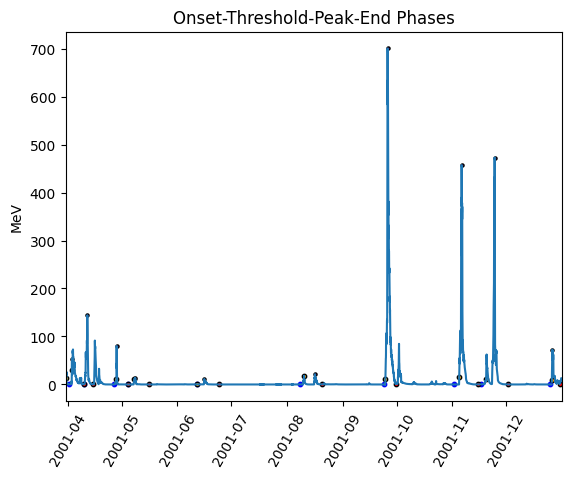

In [ ]:
phase_data_df = Find_Peak_Range_Indexes(proton_flux_df, 200)

plt.title("Onset-Threshold-Peak-End Phases")
plt.ylabel("MeV")
plt.style.use("default")
plt.plot(proton_flux_df["Timestamp"], proton_flux_df["P_tot"])


plt.scatter(phase_data_df["Timestamp Onset"], phase_data_df["Onset Flux"], c = "blue", s = 10 )


plt.scatter(phase_data_df["Threshold Timestamp"], phase_data_df["Threshold Flux"], c ="orange", s = 10, edgecolors= "black" )

plt.scatter(phase_data_df["Timestamp End"], phase_data_df["End_Flux"], c ="red", s = 10, edgecolors= "black" )

plt.scatter(phase_data_df["Timestamp Peak"], phase_data_df["Peak Flux"], c = "purple", s = 5, edgecolors= "black")

plt.xticks(rotation = 60)

plt.xlim(
    pd.Timestamp("2001-03-30 19:00:00"),
    pd.Timestamp("2001-12-31 19:00:00")
)
plt.show()